<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/Class10_Lab10_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr

start = "2010-01-01"
end = "2024-12-31"

series = {
    "CPIAUCSL": "cpi",
    "UNRATE": "unrate",
    "FEDFUNDS": "fedfunds",
    "INDPRO": "indpro",
    "RSAFS": "retail_sales",
    "DGS10": "dgs10",
    "PAYEMS": "payrolls",
    "M2SL": "m2"
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1)
df = df.asfreq("MS")   # monthly frequency
df = df.dropna()   # remove missing rows

print(df.head())
print(df.shape)

                cpi  unrate  fedfunds   indpro  retail_sales  dgs10  payrolls  \
DATE                                                                            
2010-02-01  217.281     9.8      0.13  89.6779      339580.0   3.68  129706.0   
2010-03-01  217.353     9.9      0.16  90.2928      346974.0   3.61  129866.0   
2010-04-01  217.403     9.9      0.20  90.5991      349869.0   3.89  130120.0   
2010-06-01  217.199     9.4      0.18  91.9928      346516.0   3.29  130510.0   
2010-07-01  217.605     9.4      0.18  92.3421      347612.0   2.96  130415.0   

                m2  
DATE                
2010-02-01  8527.3  
2010-03-01  8523.5  
2010-04-01  8554.8  
2010-06-01  8628.1  
2010-07-01  8639.5  
(119, 8)


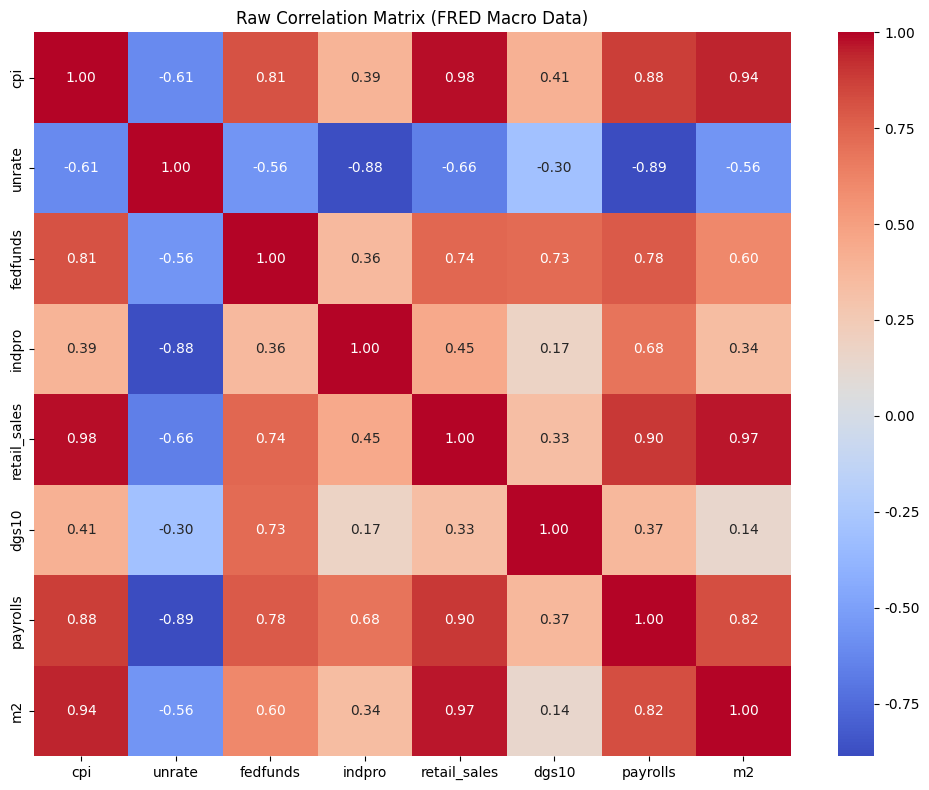

In [22]:
plt.figure(figsize=(10, 8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Raw Correlation Matrix (FRED Macro Data)")
plt.tight_layout()
plt.show()

In [23]:
y = df['cpi']

X = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls", "m2"
]]

X = sm.add_constant(X)   # add intercept

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     1812.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          2.72e-111
Time:                        21:04:17   Log-Likelihood:                -286.93
No. Observations:                 119   AIC:                             589.9
Df Residuals:                     111   BIC:                             612.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           30.1494     45.088      0.669   

In [24]:
_vif = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls", "m2"
]].copy()

X_vif = sm.add_constant(_vif)   # add constant

vif_table = pd.DataFrame()
vif_table["feature"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_table.sort_values("VIF", ascending=False))

        feature           VIF
0         const  31016.958443
4  retail_sales     88.903153
7            m2     85.800800
6      payrolls     78.213803
1        unrate     34.232893
2      fedfunds     17.457651
3        indpro      6.079591
5         dgs10      4.662524


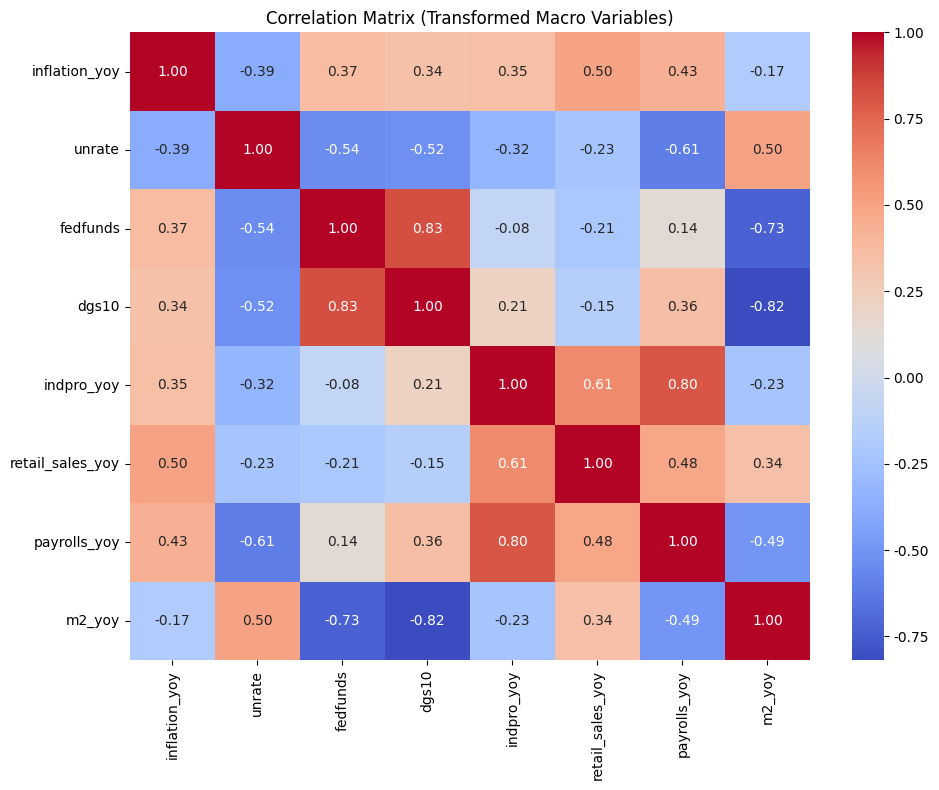

In [25]:
df_t = df.copy()

for col in ["cpi", "payrolls", "retail_sales", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = df_t[col].pct_change(12) * 100

df_t["inflation_yoy"] = df_t["cpi_yoy"]

use_cols = [
    "inflation_yoy", "unrate", "fedfunds", "dgs10",
    "indpro_yoy", "retail_sales_yoy", "payrolls_yoy", "m2_yoy"
]

df_t = df_t[use_cols].dropna()   # select columns + drop NA

plt.figure(figsize=(10, 8))
sns.heatmap(df_t.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Transformed Macro Variables)")
plt.tight_layout()
plt.show()

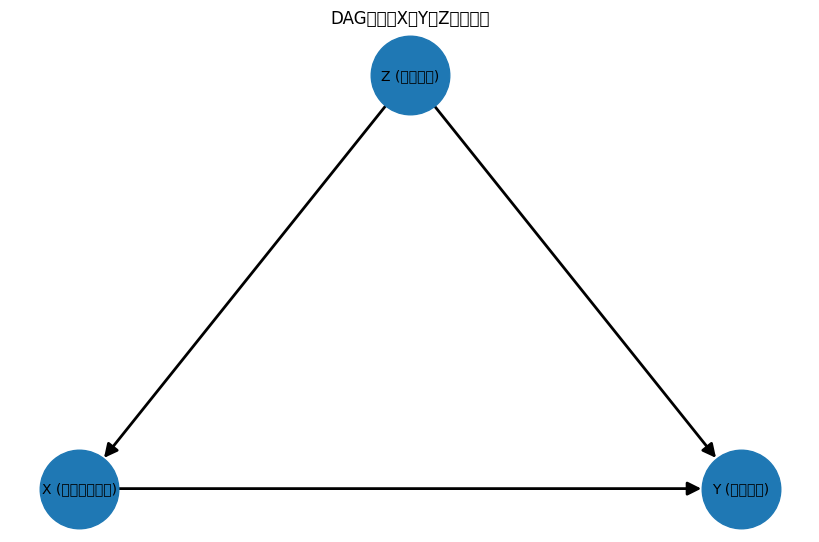

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 安装字体
!sudo apt-get update
!sudo apt-get install -y fonts-noto-cjk

# 更新 matplotlib 字体缓存
!rm -rf ~/.cache/matplotlib
fm._load_fontmanager(try_read_cache=False) # 重新加载字体管理器

# 配置 matplotlib 以支持中文字符
font_name = 'Noto Sans CJK SC'
if fm.findfont(font_name, fallback_to_default=False):
    plt.rcParams['font.sans-serif'] = [font_name]  # 使用安装的 Noto Sans CJK SC 字体
    print(f"✅ 字体 '{font_name}' 已成功加载。")
else:
    print(f"❌ 字体 '{font_name}' 未找到，请尝试重启运行时后重试。")
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

G = nx.DiGraph()

# X = 政策率，Y = 通货膨胀率，Z = 混杂因素
G.add_edges_from([
    ("Z (需求冲击)", "X (联邦基金利率)"),
    ("Z (需求冲击)", "Y (通货膨胀)"),
    ("X (联邦基金利率)", "Y (通货膨胀)")  # 可选直接因果路径
])

pos = {
    "Z (需求冲击)": (0, 1),
    "X (联邦基金利率)": (-1, 0),
    "Y (通货膨胀)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG示例：X、Y和Z混杂因素")
plt.axis("off")
plt.show()

✅ 安装完成
✅ 所有库导入成功
正在从 FRED 下载数据...
  ✓ CPI             (CPIAUCSL)
  ✓ CorePCE         (PCEPILFE)
  ✓ FedFunds        (FEDFUNDS)
  ✓ Unemployment    (UNRATE)
  ✓ M2              (M2SL)
  ✓ RealIncome      (DSPIC96)
  ✓ OilPrice        (MCOILWTICO)
  ✓ PPI             (PPIFIS)


  ✓ ConsConf        (UMCSENT)

原始数据：171 行 × 9 列
时间范围：2009-11-01 ～ 2024-01-01

YoY数据维度：(159, 11)
前5行预览：

========== ADF 单位根检验 ==========
变量                                 ADF统计量       p值           结论
─────────────────────────────────────────────────────────────────
CPI_yoy                           -1.7939   0.3835       ⚠️ 非平稳
FedFunds_level                    -2.1170   0.2377       ⚠️ 非平稳
Unemployment_level                -2.9763   0.0372         ✅ 平稳
M2_yoy                            -2.6429   0.0845       ⚠️ 非平稳
OilPrice_yoy                      -4.0397   0.0012         ✅ 平稳
PPI_yoy                           -2.0596   0.2611       ⚠️ 非平稳
ConsConf_yoy                      -1.9028   0.3307       ⚠️ 非平稳


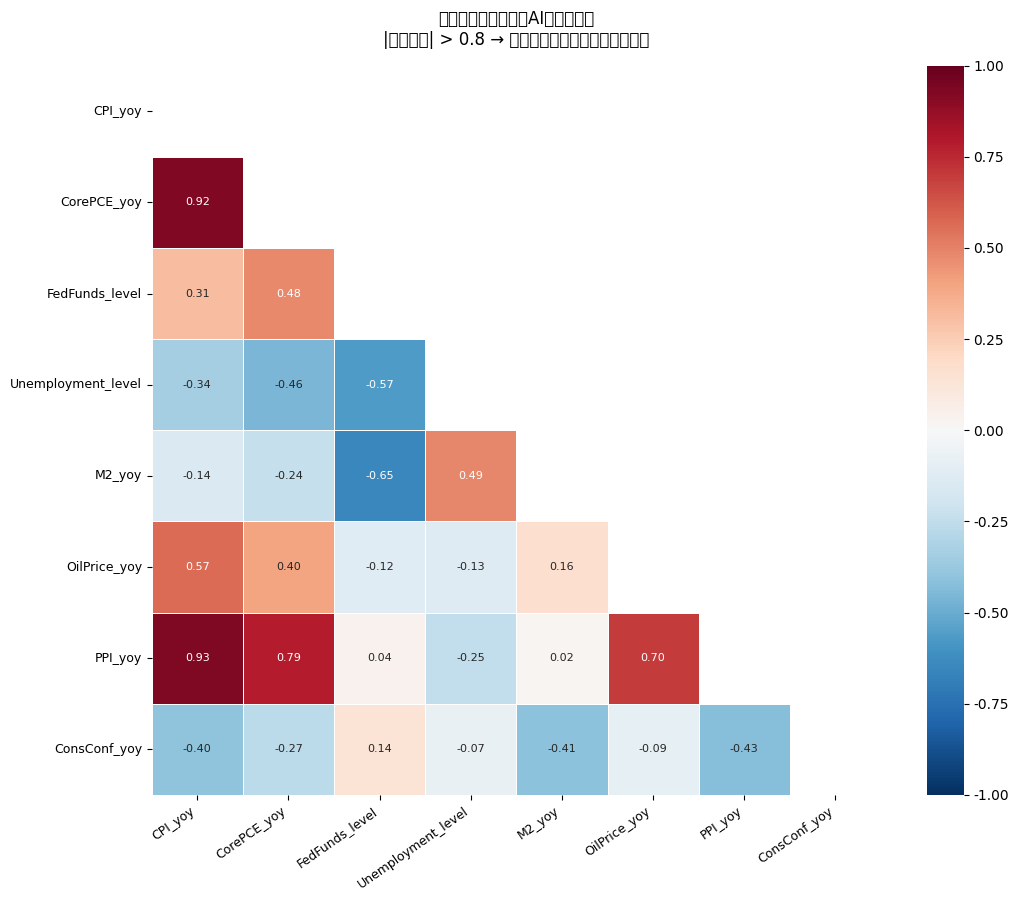


========== 基准 OLS 回归结果 ==========
                            OLS Regression Results                            
Dep. Variable:                CPI_yoy   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     414.7
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.60e-91
Time:                        21:12:03   Log-Likelihood:                -113.67
No. Observations:                 159   AIC:                             241.3
Df Residuals:                     152   BIC:                             262.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
c


╔══════════════════════════════════════════════════════════════════╗
║       ⚠️  6条虚假推断的假设与风险（务必在课堂说明）              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  风险1：内生性（Endogeneity）                     ❗❗❗ 最严重   ║
║  问题：Fed 根据通胀预期主动调整利率                              ║
║       → 利率(X) 与 误差项 相关 → OLS假设被违反                  ║
║  后果：FedFunds 的 OLS 系数有偏，不能解读为因果效应             ║
║  解法：工具变量（IV）、局部投影（Local Projections）             ║
║                                                                  ║
║  风险2：反向因果（Reverse Causality）             ❗❗❗ 最严重   ║
║  问题：正相关观测 = 通胀↑ → Fed加息（而非加息→通胀↑）          ║
║  后果：系数符号可能为正，但原因是因果方向搞反了                  ║
║  参见：DAG分析（第6步）                                          ║
║                                                                  ║
║  风险3：省略变量偏差（OVB）                       ❗❗ 严重      ║
║  问题：通胀预期（未完全观测）同时影响利率和通胀                  ║
║       供应链冲击、全球化趋势未纳入模型     

In [30]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  第7步：AI辅助扩展分析 — 通货膨胀动态宏观计量实验室              ║
# ║  直接复制到 Google Colab 运行                                    ║
# ║  唯一需要修改：把 your_api_key_here 换成你的 FRED API Key        ║
# ╚══════════════════════════════════════════════════════════════════╝

# ============================================================
# 【第0块】安装依赖库
# 说明：Colab 已内置 pandas/numpy/matplotlib，但需要额外安装这两个
# ============================================================
!pip install fredapi plotly statsmodels --quiet
print("✅ 安装完成")

# ============================================================
# 【第1块】导入所有需要的库
# ============================================================
import pandas as pd                                          # 数据处理
import numpy as np                                           # 数值计算
import matplotlib.pyplot as plt                              # 静态绘图
import seaborn as sns                                        # 相关性热图
import plotly.graph_objects as go                            # 交互式绘图
from plotly.subplots import make_subplots                    # 多子图布局
import statsmodels.api as sm                                 # OLS回归
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF检验
from statsmodels.tsa.stattools import adfuller               # ADF单位根检验
from fredapi import Fred                                     # FRED数据接口
import warnings
warnings.filterwarnings('ignore')
print("✅ 所有库导入成功")

# ============================================================
# 【第2块】连接 FRED API，下载9个宏观变量
#
# 【原有3个变量】
#   CPIAUCSL  → CPI消费者价格指数（衡量通胀最常用指标）
#   FEDFUNDS  → 联邦基金利率（美联储货币政策工具）
#   UNRATE    → 失业率（劳动力市场松紧度）
#
# 【AI新增3个变量，理由如下】
#   MCOILWTICO → WTI原油价格
#     理由：石油是生产成本的核心投入，油价↑→生产成本↑→PPI↑→CPI↑
#           油价冲击是典型的"供给侧通胀"来源，与需求侧通胀机制不同
#
#   PPIFIS     → 生产者价格指数（PPI）
#     理由：PPI是CPI的"上游先行指标"，生产者先涨价，消费者后涨价
#           加入PPI可以检验通胀的传导链条是否完整
#
#   UMCSENT    → 密歇根大学消费者信心指数
#     理由：消费者信心是通胀预期的代理变量
#           通胀预期本身就能推动通胀（工资谈判、定价行为）
#           这是DAG中"省略变量W"的可观测近似
#
# 【其他辅助变量】
#   PCEPILFE  → 核心PCE（美联储官方目标变量，剔除食品+能源）
#   M2SL      → M2货币供给（货币数量论的核心变量）
#   DSPIC96   → 实际可支配收入（需求侧压力）
# ============================================================
FRED_API_KEY = "87f1179f9600bfc6185da03c525f22b4"   # ← 替换为你自己的Key
fred = Fred(api_key=FRED_API_KEY)

START_DATE = "1990-01-01"
END_DATE   = "2024-01-01"

# 变量名称 → FRED代码 的映射字典
SERIES = {
    "CPI"          : "CPIAUCSL",    # 消费者价格指数（水平）
    "CorePCE"      : "PCEPILFE",    # 核心PCE（水平）
    "FedFunds"     : "FEDFUNDS",    # 联邦基金利率（%）
    "Unemployment" : "UNRATE",      # 失业率（%）
    "M2"           : "M2SL",        # M2货币供给（十亿美元）
    "RealIncome"   : "DSPIC96",     # 实际可支配收入（十亿美元）
    "OilPrice"     : "MCOILWTICO",  # WTI原油价格（美元/桶）
    "PPI"          : "PPIFIS",      # 生产者价格指数
    "ConsConf"     : "UMCSENT",     # 消费者信心指数
}

print("正在从 FRED 下载数据...")
raw_data = {}
for var_name, fred_code in SERIES.items():
    try:
        raw_data[var_name] = fred.get_series(fred_code, START_DATE, END_DATE)
        print(f"  ✓ {var_name:15s} ({fred_code})")
    except Exception as error:
        print(f"  ✗ {var_name:15s} ({fred_code}) 失败: {error}")

# 合并为月度DataFrame：resample确保月度频率，fillna向前填充缺失值
df_raw = (pd.DataFrame(raw_data)
            .resample("MS").last()
            .fillna(method="ffill")
            .dropna())

print(f"\n原始数据：{df_raw.shape[0]} 行 × {df_raw.shape[1]} 列")
print(f"时间范围：{df_raw.index[0].date()} ～ {df_raw.index[-1].date()}")

# ============================================================
# 【第3块】转化为同比增长率（YoY = Year-over-Year）
#
# 为什么必须做这步？
#   - CPI/PPI/M2 的水平值有"趋势"→非平稳 → 直接OLS = 伪回归
#   - 伪回归的特征：R²很高，但回归关系毫无意义
#   - YoY公式：(当月值 - 12个月前值) / 12个月前值 × 100
#   - YoY的优点：消除趋势、消除季节性、结果有直觉经济含义
#
# 注意：利率和失业率本身就是%，不需要再算增长率，保留水平值
# ============================================================
df_yoy = df_raw.pct_change(periods=12) * 100  # 12期=12个月=同比
df_yoy.columns = [col + "_yoy" for col in df_yoy.columns]  # 重命名加后缀

# 利率和失业率保留原始水平值（直接覆盖YoY列）
df_yoy["FedFunds_level"]     = df_raw["FedFunds"]
df_yoy["Unemployment_level"] = df_raw["Unemployment"]

df_yoy = df_yoy.dropna()  # 删除YoY计算产生的前12行NaN

print(f"\nYoY数据维度：{df_yoy.shape}")
print("前5行预览：")
df_yoy[["CPI_yoy", "FedFunds_level", "Unemployment_level", "OilPrice_yoy"]].head()

# ============================================================
# 【第4块】ADF 单位根检验
#
# 目的：验证YoY转化之后序列是否真的平稳
# 原假设 H0：序列有单位根（非平稳）
# 结论逻辑：p值 < 0.05 → 拒绝H0 → 序列平稳 → 可以放心做OLS
#
# ⚠️ 风险提示：若某变量ADF检验不平稳，该变量的OLS系数不可信
# ============================================================
print("\n========== ADF 单位根检验 ==========")
print(f"{'变量':<28} {'ADF统计量':>12} {'p值':>8} {'结论':>12}")
print("─" * 65)

check_vars = ["CPI_yoy", "FedFunds_level", "Unemployment_level",
              "M2_yoy", "OilPrice_yoy", "PPI_yoy", "ConsConf_yoy"]

for var in check_vars:
    if var in df_yoy.columns:
        adf_stat, p_val = adfuller(df_yoy[var].dropna())[:2]
        conclusion = "✅ 平稳" if p_val < 0.05 else "⚠️ 非平稳"
        print(f"{var:<28} {adf_stat:>12.4f} {p_val:>8.4f} {conclusion:>12}")

# ============================================================
# 【第5块】扩展相关性热图
#
# 目的：视觉识别多共线性风险（相关系数绝对值 > 0.8 = 危险）
# 颜色含义：红色 = 正相关，蓝色 = 负相关
# 关注：CPI_yoy 与哪些变量高度相关？（这些变量不能同时入模型）
# ============================================================
corr_vars = ["CPI_yoy", "CorePCE_yoy", "FedFunds_level",
             "Unemployment_level", "M2_yoy", "OilPrice_yoy",
             "PPI_yoy", "ConsConf_yoy"]
corr_vars = [v for v in corr_vars if v in df_yoy.columns]

corr_matrix = df_yoy[corr_vars].corr()

# 只显示下三角（上三角是重复信息）
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # 显示数值
    fmt=".2f",           # 保留2位小数
    cmap="RdBu_r",       # 红蓝发散色板
    center=0,            # 中心=0（无相关）
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 8}
)
plt.title("扩展相关性热图（含AI新增变量）\n|相关系数| > 0.8 → 多共线性风险，不可同时入模型",
          fontsize=12, pad=15)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("corr_heatmap_extended.png", dpi=150)
plt.show()

# ============================================================
# 【第6块】基准 OLS 回归 + VIF 多共线性诊断
#
# 因变量 Y：CPI通胀（YoY）
# 自变量 X：利率、失业率、M2增速、油价增速、PPI增速、消费者信心增速
#
# 注意：CorePCE与CPI高度相关（相关系数>0.95），故排除以避免多共线性
#
# ⚠️ 风险提示：
#   - 这个OLS是"天真回归"（naive regression），存在内生性问题
#   - FedFunds系数不能解读为"利率对通胀的因果效应"
#   - 参见DAG分析：反向因果和共同冲击会使系数有偏
# ============================================================
# 因变量
Y_base = df_yoy["CPI_yoy"]

# 自变量（选择经济逻辑清晰、多共线性较低的变量）
X_base = df_yoy[[
    "FedFunds_level",       # 货币政策
    "Unemployment_level",   # 劳动力市场
    "M2_yoy",               # 货币供给增速
    "OilPrice_yoy",         # 供给侧冲击
    "PPI_yoy",              # 上游通胀压力
    "ConsConf_yoy",         # 通胀预期代理
]].dropna()

# 对齐因变量和自变量的时间索引
common_idx = Y_base.index.intersection(X_base.index)
Y_base = Y_base.loc[common_idx]
X_base = X_base.loc[common_idx]

X_base_const = sm.add_constant(X_base)   # 加入截距项（const）

# 估计OLS模型
model_base = sm.OLS(Y_base, X_base_const).fit()

print("\n========== 基准 OLS 回归结果 ==========")
print(model_base.summary())

# VIF检验：衡量每个自变量与其他自变量的线性相关程度
# VIF = 1/(1-R²_j)，R²_j = 第j个变量对其余变量回归的R²
vif_table = pd.DataFrame({
    "变量" : X_base_const.columns,
    "VIF"  : [variance_inflation_factor(X_base_const.values, i)
              for i in range(X_base_const.shape[1])]
})
print("\n========== VIF 多共线性诊断 ==========")
print(vif_table.round(2).to_string(index=False))
print("\nVIF判断标准：< 5 ✅ 无问题 | 5~10 ⚠️ 需注意 | > 10 ❌ 严重多共线性")

# ============================================================
# 【第7块】稳健性检验1 — 滞后变量（Lag Analysis）
#
# 经济逻辑：
#   货币政策影响通胀有"时滞"（传导链条需要时间）
#   加息 → 贷款成本↑ → 投资↓ → 需求↓ → 通胀↓
#   这个链条通常需要 6~18 个月
#
# 检验方法：
#   对比 FedFunds 同期、滞后6期（半年）、滞后12期（一年）的系数
#   若滞后12期系数变为显著负值 → 支持"加息确实降低通胀，但有时滞"
#
# ⚠️ 风险提示：
#   即使加入滞后，内生性问题仍未解决
#   （Fed对未来通胀预期加息，而非仅对当前通胀反应）
# ============================================================
print("\n========== 稳健性检验1：FedFunds 滞后效应对比 ==========")
print(f"{'滞后期数':<10} {'FedFunds系数':>15} {'p值':>10} {'R²':>10} {'样本量':>8}")
print("─" * 55)

for lag_periods in [0, 6, 12]:
    df_lag_test = df_yoy.copy()

    # 生成滞后变量
    if lag_periods == 0:
        fed_col = "FedFunds_level"
    else:
        fed_col = f"FedFunds_lag{lag_periods}"
        df_lag_test[fed_col] = df_lag_test["FedFunds_level"].shift(lag_periods)

    # 准备回归数据
    X_lag = df_lag_test[[fed_col, "Unemployment_level",
                          "M2_yoy", "OilPrice_yoy", "PPI_yoy"]].dropna()
    Y_lag = df_lag_test["CPI_yoy"].loc[X_lag.index]

    # 估计模型
    model_lag = sm.OLS(Y_lag, sm.add_constant(X_lag)).fit()

    coef = model_lag.params[fed_col]
    pval = model_lag.pvalues[fed_col]
    r2   = model_lag.rsquared
    n    = len(Y_lag)
    sig  = "**" if pval < 0.05 else ("*" if pval < 0.10 else "")
    print(f"滞后{lag_periods:>2}期{'':<4} {coef:>15.4f} {pval:>10.4f}{sig:<2} {r2:>10.4f} {n:>8}")

print("\n💡 解读：若滞后12期系数为负且显著 → 加息对通胀有延迟抑制效果")
print("         若系数始终为正 → 反向因果占主导（通胀高→Fed加息的信号更强）")

# ============================================================
# 【第8块】稳健性检验2 — 子样本（排除危机期）
#
# 经济逻辑：
#   金融危机（2008-09）和COVID（2020）是罕见的极端外生冲击
#   这些时期的数据是"高影响力观测值"，可能主导整个回归估计
#   排除危机期后，检验"正常经济时期"的规律是否稳健
#
# ⚠️ 风险提示：
#   人为选择"危机"时段本身带有主观性
#   应同时报告完整样本结果作为基准对比
# ============================================================
# 定义需要排除的危机时段
crisis_filter = (
    ((df_yoy.index >= "2008-09-01") & (df_yoy.index <= "2009-12-01")) |  # 全球金融危机
    ((df_yoy.index >= "2020-02-01") & (df_yoy.index <= "2021-06-01"))    # COVID冲击
)
df_no_crisis = df_yoy[~crisis_filter].copy()  # ~ 表示"取反"，即保留非危机期

print("\n========== 稳健性检验2：子样本（排除危机期）==========")
print(f"完整样本：{len(df_yoy)} 个月 | 排除危机后：{len(df_no_crisis)} 个月")

X_nc = df_no_crisis[["FedFunds_level", "Unemployment_level",
                      "M2_yoy", "OilPrice_yoy", "PPI_yoy"]].dropna()
Y_nc = df_no_crisis["CPI_yoy"].loc[X_nc.index]
model_nc = sm.OLS(Y_nc, sm.add_constant(X_nc)).fit()

# 关键系数对比表
compare_vars = ["FedFunds_level", "Unemployment_level", "OilPrice_yoy"]
comparison_df = pd.DataFrame({
    "完整样本系数" : model_base.params[compare_vars].round(4),
    "完整样本p值"  : model_base.pvalues[compare_vars].round(4),
    "排危机系数"   : model_nc.params[compare_vars].round(4),
    "排危机p值"    : model_nc.pvalues[compare_vars].round(4),
})
print("\n关键系数对比：")
print(comparison_df)
print(f"\nR²：完整样本 = {model_base.rsquared:.4f} | 排危机后 = {model_nc.rsquared:.4f}")
print("💡 若系数方向或显著性大幅变化 → 原结果由危机期极端值驱动，结论不稳健")

# ============================================================
# 【第9块】交互式 Plotly 三面板图表
#
# 图表结构：
#   上方（40%）：CPI通胀 vs 核心PCE通胀（两条线对比）
#   中间（30%）：联邦基金利率（面积图）
#   下方（30%）：失业率（面积图）
#   灰色阴影  ：NBER官方衰退期
#   悬停功能  ：鼠标悬停同步显示三个变量的值
# ============================================================

# NBER官方衰退时段（开始日期，结束日期，名称）
nber_recessions = [
    ("1990-07-01", "1991-03-01", "1990-91衰退"),
    ("2001-03-01", "2001-11-01", "互联网泡沫衰退"),
    ("2007-12-01", "2009-06-01", "金融危机"),
    ("2020-02-01", "2020-04-01", "COVID衰退"),
]

# 创建3行1列的共享X轴子图
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,                      # X轴联动
    subplot_titles=[
        "① CPI通胀 vs 核心PCE通胀（同比 %）",
        "② 联邦基金利率（%）",
        "③ 失业率（%）",
    ],
    vertical_spacing=0.07,
    row_heights=[0.40, 0.30, 0.30]
)

# --- 子图1：通胀指标 ---
fig.add_trace(go.Scatter(
    x=df_yoy.index,
    y=df_yoy["CPI_yoy"].round(2),
    name="CPI通胀 (YoY%)",
    line=dict(color="#E74C3C", width=2.5),
    hovertemplate="<b>CPI通胀</b>：%{y:.2f}%<extra></extra>"
), row=1, col=1)

if "CorePCE_yoy" in df_yoy.columns:
    fig.add_trace(go.Scatter(
        x=df_yoy.index,
        y=df_yoy["CorePCE_yoy"].round(2),
        name="核心PCE (YoY%)",
        line=dict(color="#E67E22", width=2, dash="dash"),
        hovertemplate="<b>核心PCE</b>：%{y:.2f}%<extra></extra>"
    ), row=1, col=1)

# Fed 2%目标参考线
fig.add_hline(y=2, line_dash="dot", line_color="#95A5A6", line_width=1.5,
              annotation_text="Fed目标 2%", annotation_font_size=10,
              row=1, col=1)

# --- 子图2：联邦基金利率 ---
fig.add_trace(go.Scatter(
    x=df_yoy.index,
    y=df_yoy["FedFunds_level"].round(2),
    name="联邦基金利率 (%)",
    line=dict(color="#2980B9", width=2.5),
    fill="tozeroy",                              # 从0填充到线
    fillcolor="rgba(41,128,185,0.08)",
    hovertemplate="<b>联邦基金利率</b>：%{y:.2f}%<extra></extra>"
), row=2, col=1)

# --- 子图3：失业率 ---
fig.add_trace(go.Scatter(
    x=df_yoy.index,
    y=df_yoy["Unemployment_level"].round(2),
    name="失业率 (%)",
    line=dict(color="#27AE60", width=2.5),
    fill="tozeroy",
    fillcolor="rgba(39,174,96,0.08)",
    hovertemplate="<b>失业率</b>：%{y:.2f}%<extra></extra>"
), row=3, col=1)

# --- 衰退阴影：在所有子图加灰色矩形 ---
cpi_max = df_yoy["CPI_yoy"].max()
for rec_start, rec_end, rec_name in nber_recessions:
    for row_num in [1, 2, 3]:
        fig.add_vrect(
            x0=rec_start, x1=rec_end,
            fillcolor="rgba(189,195,199,0.30)",
            layer="below", line_width=0,
            row=row_num, col=1
        )
    # 衰退名称标注（只在第1行）
    fig.add_annotation(
        x=rec_start, y=cpi_max * 0.88,
        text=f"<b>{rec_name}</b>",
        showarrow=False,
        font=dict(size=9, color="#7F8C8D"),
        row=1, col=1
    )

# --- 全局布局设置 ---
fig.update_layout(
    title=dict(
        text=("美国通货膨胀动态：三变量交互分析（1990–2024）<br>"
              "<sup>灰色阴影 = NBER官方衰退期 ｜ 数据来源：FRED ｜ 鼠标悬停查看数值</sup>"),
        font=dict(size=15, color="#2C3E50"),
        x=0.5
    ),
    height=780,
    hovermode="x unified",               # 悬停时同步显示所有子图数值
    legend=dict(
        orientation="h", y=-0.06, x=0.5, xanchor="center",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="#BDC3C7", borderwidth=1
    ),
    template="plotly_white",
    paper_bgcolor="#FAFAFA",
    font=dict(family="Arial", size=11, color="#2C3E50"),
    margin=dict(t=100, b=80, l=60, r=40)
)
fig.update_yaxes(ticksuffix="%", showgrid=True, gridcolor="rgba(0,0,0,0.04)")
fig.update_xaxes(showgrid=True, gridcolor="rgba(0,0,0,0.04)")

# 保存为HTML（可在浏览器打开，支持交互）
fig.write_html("inflation_interactive_dashboard.html")
print("✅ 交互式图表已保存为 inflation_interactive_dashboard.html")
fig.show()

# ============================================================
# 【第10块】虚假推断风险清单（课堂讲解用）
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════════╗
║       ⚠️  6条虚假推断的假设与风险（务必在课堂说明）              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  风险1：内生性（Endogeneity）                     ❗❗❗ 最严重   ║
║  问题：Fed 根据通胀预期主动调整利率                              ║
║       → 利率(X) 与 误差项 相关 → OLS假设被违反                  ║
║  后果：FedFunds 的 OLS 系数有偏，不能解读为因果效应             ║
║  解法：工具变量（IV）、局部投影（Local Projections）             ║
║                                                                  ║
║  风险2：反向因果（Reverse Causality）             ❗❗❗ 最严重   ║
║  问题：正相关观测 = 通胀↑ → Fed加息（而非加息→通胀↑）          ║
║  后果：系数符号可能为正，但原因是因果方向搞反了                  ║
║  参见：DAG分析（第6步）                                          ║
║                                                                  ║
║  风险3：省略变量偏差（OVB）                       ❗❗ 严重      ║
║  问题：通胀预期（未完全观测）同时影响利率和通胀                  ║
║       供应链冲击、全球化趋势未纳入模型                           ║
║  后果：现有系数"吸收"了这些省略变量的效果，产生偏差             ║
║                                                                  ║
║  风险4：结构性断点（Structural Breaks）           ❗❗ 严重      ║
║  问题：2008危机后出现量化宽松（QE），改变了政策传导机制          ║
║  后果：用 1990-2024 单一回归强加了不存在的"稳定关系"           ║
║  检验：子样本对比（第8块）部分缓解                              ║
║                                                                  ║
║  风险5：多重共线性（Multicollinearity）           ❗ 中等        ║
║  问题：CPI ≈ CorePCE（相关>0.95）；PPI 与 CPI 也高度相关       ║
║  后果：系数标准误膨胀，显著性失真                               ║
║  检验：VIF > 10 的变量需排除（第6块）                           ║
║                                                                  ║
║  风险6：非平稳性（Non-stationarity）              ❗ 中等        ║
║  问题：若 ADF 检验未通过，YoY序列仍含单位根                     ║
║  后果：高R²但回归毫无意义（伪回归）                              ║
║  检验：ADF 检验（第4块），p>0.05 的变量需进一步差分             ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")
